In [2]:
import os, cv2
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
from torchvision import transforms

In [3]:
# ========== 1. EXPLORE DATASET STRUCTURE ==========
data_path = "../archive"

dirs = sorted(os.listdir(data_path))
print(dirs)
train_dir = os.path.join(data_path, dirs[1])
test_dir  = os.path.join(data_path, dirs[0])

train_classes = sorted(os.listdir(train_dir))
test_classes  = sorted(os.listdir(test_dir))

print("Les classes de Training :", train_classes)
print("Les classes de Test     :", test_classes)

def count_images_in_folder(folder):
    counts = {}
    for cls in sorted(os.listdir(folder)):
        cls_dir = os.path.join(folder, cls)
        files = [f for f in os.listdir(cls_dir)
                 if f.lower().endswith(('.png','.jpg','.jpeg'))]
        counts[cls] = len(files)
    return counts

train_counts = count_images_in_folder(train_dir)
test_counts  = count_images_in_folder(test_dir)

print("Training set:\n", train_counts)
print("Testing set:\n", test_counts)

['Testing', 'Training']
Les classes de Training : ['glioma', 'meningioma', 'notumor', 'pituitary']
Les classes de Test     : ['glioma', 'meningioma', 'notumor', 'pituitary']
Training set:
 {'glioma': 1321, 'meningioma': 1339, 'notumor': 1595, 'pituitary': 1457}
Testing set:
 {'glioma': 300, 'meningioma': 306, 'notumor': 405, 'pituitary': 300}


In [4]:
shapes = []

for cls in train_classes:
    cls_dir = os.path.join(train_dir, cls)
    files = [f for f in os.listdir(cls_dir) if f.lower().endswith(('.png','.jpg','.jpeg'))]
    for f in files[:50]:
        img = Image.open(os.path.join(cls_dir, f))
        shapes.append(img.size)

print("Unique shapes (sample):", sorted(set(shapes))[:10])


Unique shapes (sample): [(201, 210), (202, 202), (206, 244), (220, 212), (224, 286), (225, 225), (234, 224), (235, 229), (235, 233), (236, 218)]


In [5]:
# ======= PREPROCESSING FUNCTIONS =======

def crop_black(img):
    """Crop black borders around the brain area."""
    coords = cv2.findNonZero(img)
    if coords is None:
        return img
    x, y, w, h = cv2.boundingRect(coords)
    return img[y:y+h, x:x+w]

def preprocess_image(img_path,  target_size=(224, 224)):
    """Full preprocessing pipeline for one image."""
    # 1. Read grayscale
    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        return None

    # 2. Crop black borders
    img = crop_black(img)

    # 3. CLAHE contrast enhancement
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
    img = clahe.apply(img)

    # 4. Bilateral denoising
    img = cv2.bilateralFilter(img, d=5, sigmaColor=20, sigmaSpace=50)

    '''# 5. Adaptive Gaussian thresholding (with Otsu-like local adaptation)
    img = cv2.adaptiveThreshold(
        img, 255,
        cv2.ADAPTIVE_THRESH_GAUSSIAN_C, cv2.THRESH_BINARY,
        blockSize=11, C=2
    )'''

    # 5. Resize to target size
    img = cv2.resize(img, target_size, interpolation=cv2.INTER_AREA)
    
    # 6. Normalize to [0, 1]
    img = img.astype(np.float32) / 255.0
    
    return img


In [7]:
from tqdm import tqdm

# ========== PREPROCESS AND SAVE ENTIRE DATASET ==========

OUTPUT_PATH = "../preprocessed_data"
TARGET_SIZE = (224, 224)

def preprocess_and_save_dataset(input_dir, output_dir, target_size=(224, 224)):
    """
    Preprocess all images and save them.
    
    Args:
        input_dir: Path to original dataset (Training or Testing)
        output_dir: Path to save preprocessed images
        target_size: Image size (width, height)
    """
    
    # Get all classes
    classes = sorted(os.listdir(input_dir))
    
    print(f"\n{'='*60}")
    print(f"Processing: {input_dir}")
    print(f"Output: {output_dir}")
    print(f"Classes: {classes}")
    print(f"{'='*60}\n")
    
    for cls in classes:
        # Create output directory for this class
        input_cls_dir = os.path.join(input_dir, cls)
        output_cls_dir = os.path.join(output_dir, cls)
        os.makedirs(output_cls_dir, exist_ok=True)
        
        # Get all images in this class
        files = [f for f in os.listdir(input_cls_dir) 
                 if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
        
        print(f"\nProcessing {cls}: {len(files)} images")
        
        # Process each image
        success_count = 0
        for filename in tqdm(files, desc=f"  {cls}"):
            input_path = os.path.join(input_cls_dir, filename)
            output_path = os.path.join(output_cls_dir, filename)
            
            # Preprocess
            img = preprocess_image(input_path, target_size=target_size)
            
            if img is not None:
                # Convert back to uint8 for saving
                img_uint8 = (img * 255).astype(np.uint8)
                
                # Save
                cv2.imwrite(output_path, img_uint8)
                success_count += 1
        
        print(f"  ✓ Saved {success_count}/{len(files)} images")
    
    print(f"\n{'='*60}")
    print("✓ PREPROCESSING COMPLETE!")
    print(f"{'='*60}\n")

# ========== PROCESS TRAINING SET ==========
print("\n🔄 PROCESSING TRAINING SET...")
train_output = os.path.join(OUTPUT_PATH, "Training")
preprocess_and_save_dataset(train_dir, train_output, target_size=TARGET_SIZE)

# ========== PROCESS TESTING SET ==========
print("\n🔄 PROCESSING TESTING SET...")
test_output = os.path.join(OUTPUT_PATH, "Testing")
preprocess_and_save_dataset(test_dir, test_output, target_size=TARGET_SIZE)

print("\n✅ ALL DONE!")
print(f"Preprocessed data saved to: {OUTPUT_PATH}")


🔄 PROCESSING TRAINING SET...

Processing: ../archive\Training
Output: ../preprocessed_data\Training
Classes: ['glioma', 'meningioma', 'notumor', 'pituitary']


Processing glioma: 1321 images


  glioma: 100%|████████████████████████████████████████████████████████████████████| 1321/1321 [00:27<00:00, 47.44it/s]


  ✓ Saved 1321/1321 images

Processing meningioma: 1339 images


  meningioma: 100%|████████████████████████████████████████████████████████████████| 1339/1339 [00:29<00:00, 45.76it/s]


  ✓ Saved 1339/1339 images

Processing notumor: 1595 images


...

  ✓ Saved 306/306 images

Processing notumor: 405 images


  notumor: 100%|█████████████████████████████████████████████████████████████████████| 405/405 [00:06<00:00, 62.55it/s]


  ✓ Saved 405/405 images

Processing pituitary: 300 images


  pituitary: 100%|███████████████████████████████████████████████████████████████████| 300/300 [00:07<00:00, 41.36it/s]

  ✓ Saved 300/300 images

✓ PREPROCESSING COMPLETE!


✅ ALL DONE!
Preprocessed data saved to: ../preprocessed_data


In [8]:
# ========== VERIFY PREPROCESSED DATA ==========
def verify_preprocessed_data(preprocessed_path):
    """Check the preprocessed dataset."""
    
    print(f"\n{'='*60}")
    print("VERIFICATION")
    print(f"{'='*60}\n")
    
    for split in ['Training', 'Testing']:
        split_dir = os.path.join(preprocessed_path, split)
        if not os.path.exists(split_dir):
            print(f"⚠ {split} directory not found!")
            continue
        
        print(f"\n{split}:")
        classes = sorted(os.listdir(split_dir))
        
        for cls in classes:
            cls_dir = os.path.join(split_dir, cls)
            files = [f for f in os.listdir(cls_dir) 
                    if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
            
            # Load one sample to check
            if files:
                sample_path = os.path.join(cls_dir, files[0])
                img = cv2.imread(sample_path, cv2.IMREAD_GRAYSCALE)
                
                print(f"  {cls:12} - {len(files):4} images | "
                      f"Shape: {img.shape} | "
                      f"Range: [{img.min()}, {img.max()}]")
    
    print(f"\n{'='*60}")
    print("✓ VERIFICATION COMPLETE!")
    print(f"{'='*60}\n")

# Run verification
verify_preprocessed_data(OUTPUT_PATH)


VERIFICATION


Training:
  glioma       - 1321 images | Shape: (224, 224) | Range: [1, 247]
  meningioma   - 1339 images | Shape: (224, 224) | Range: [0, 247]
  notumor      - 1595 images | Shape: (224, 224) | Range: [0, 255]
  pituitary    - 1457 images | Shape: (224, 224) | Range: [1, 248]

Testing:
  glioma       -  300 images | Shape: (224, 224) | Range: [1, 249]
  meningioma   -  306 images | Shape: (224, 224) | Range: [0, 255]
  notumor      -  405 images | Shape: (224, 224) | Range: [1, 255]
  pituitary    -  300 images | Shape: (224, 224) | Range: [0, 249]

✓ VERIFICATION COMPLETE!



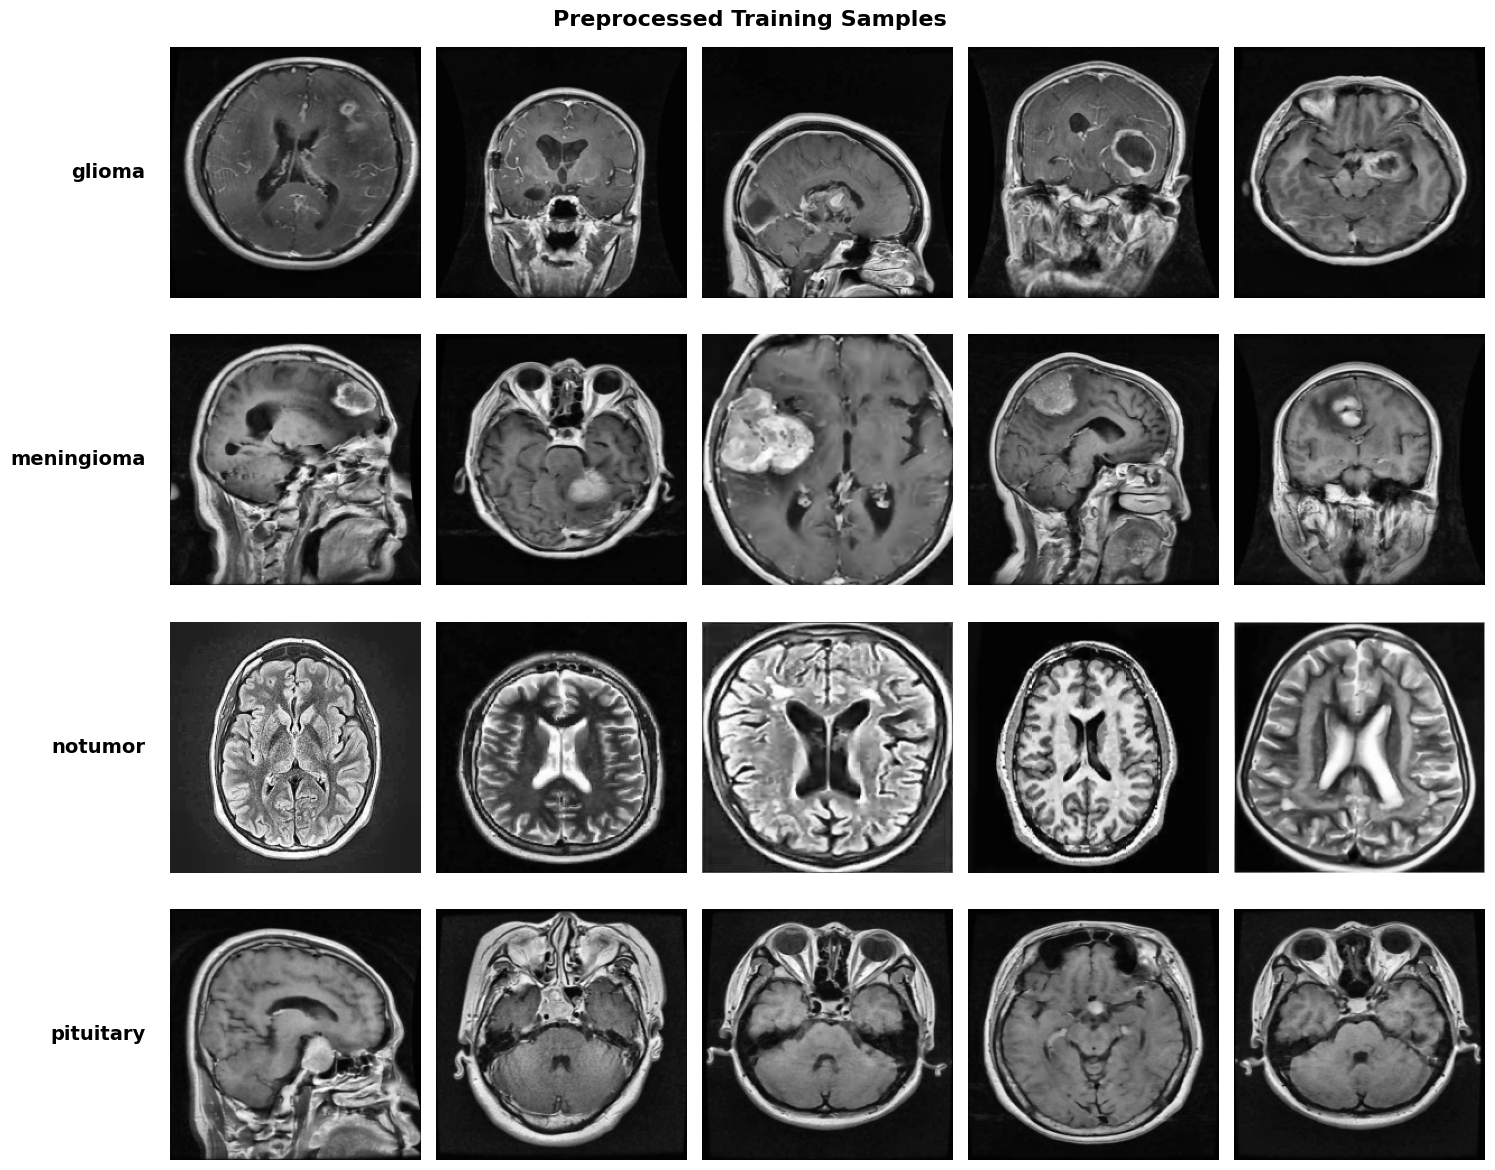

In [9]:
# ========== VISUALIZE PREPROCESSED SAMPLES ==========
import random

def visualize_preprocessed_samples(preprocessed_path, samples_per_class=5):
    """Show some preprocessed images."""
    
    train_dir = os.path.join(preprocessed_path, "Training")
    classes = sorted(os.listdir(train_dir))
    
    fig, axes = plt.subplots(len(classes), samples_per_class, 
                             figsize=(15, len(classes) * 3))
    
    for i, cls in enumerate(classes):
        cls_dir = os.path.join(train_dir, cls)
        files = [f for f in os.listdir(cls_dir) 
                if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
        
        # Random sample
        sampled = random.sample(files, min(samples_per_class, len(files)))
        
        for j, filename in enumerate(sampled):
            img_path = os.path.join(cls_dir, filename)
            img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
            
            axes[i, j].imshow(img, cmap='gray')
            axes[i, j].axis('off')
            
            if j == 0:
                axes[i, j].text(-0.1, 0.5, cls,
                              transform=axes[i, j].transAxes,
                              fontsize=14, fontweight='bold',
                              va='center', ha='right')
    
    plt.suptitle("Preprocessed Training Samples", 
                fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()

# Visualize
visualize_preprocessed_samples(OUTPUT_PATH, samples_per_class=5)